# Data explorations

Explore the shapes of the in-distribution (`load_data`) and perturbation (`get_perturbation_trials`) datasets.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from data.dataloader import (
    load_data,
    get_perturbation_trials,
    VISUAL_AREAS,
    SESSION_ID,
    DT,
    TRIAL_DURATION_S,
    PERTURB_DUR_S,
    PERTURB_PRE_S,
)

/Users/dendun/GitHub/perturbation_testing_tutorial/.venv/lib/python3.11/site-packages/allensdk/core/brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## Parameters

Change these to load different subsets of the data.

In [2]:
# --- Which areas to load (subset or all) ---
# Options: any subset of VISUAL_AREAS = ["VISp", "VISrl", "VISl", "VISal", "VISpm", "VISam"]
areas = VISUAL_AREAS  # load all areas
# areas = ["VISp"]     # just primary visual cortex

# --- Which stimulus parameter defines a condition ---
# Options: "ori" (orientation), "contrast", "speed", "all" (full condition id)
drifting_conditions = "ori"

# --- Time bin size (seconds) ---
dt = DT  # 0.01 s = 10 ms

print(f"Session:             {SESSION_ID}")
print(f"Areas:               {areas}")
print(f"Condition grouping:  {drifting_conditions}")
print(f"Bin size:            {dt*1000:.0f} ms")
print(f"Trial duration:      {TRIAL_DURATION_S} s  -> {int(TRIAL_DURATION_S/dt)} bins")
print(f"Perturb duration:    {PERTURB_DUR_S} s  -> {int(PERTURB_DUR_S/dt)} bins")

Session:             829720705
Areas:               ['VISp', 'VISrl', 'VISl', 'VISal', 'VISpm', 'VISam']
Condition grouping:  ori
Bin size:            10 ms
Trial duration:      2.0 s  -> 200 bins
Perturb duration:    1.5 s  -> 150 bins


## In-distribution data (train / test)

Raster tensor shape: **(n_trials, n_neurons, n_bins)**  
Condition vector shape: **(n_trials,)**

In [3]:
c_train, z_train, c_test, z_test, area_per_neuron, sign_per_neuron = load_data(
    areas=areas,
    drifting_conditions=drifting_conditions,
    dt=dt,
    time_last=True,  # shape (B, N, T)
)

print("=== In-distribution shapes ===")
print(f"z_train:           {z_train.shape}  (trials, neurons, time bins)")
print(f"c_train:           {c_train.shape}  (trial condition ids)")
print(f"z_test:            {z_test.shape}")
print(f"c_test:            {c_test.shape}")
print(f"area_per_neuron:   {area_per_neuron.shape}  dtype={area_per_neuron.dtype}")
print(f"sign_per_neuron:   {sign_per_neuron.shape}  dtype={sign_per_neuron.dtype}")
print()
print("=== Conditions ===")
for cid in sorted(np.unique(c_train)):
    label = "spontaneous" if cid == 0 else f"drifting grating (c={cid})"
    n = int((c_train == cid).sum())
    print(f"  c={cid:2d}  {label:<30s}  {n} train trials")

=== In-distribution shapes ===
z_train:           (1236, 371, 200)  (trials, neurons, time bins)
c_train:           (1236,)  (trial condition ids)
z_test:            (529, 371, 200)
c_test:            (529,)
area_per_neuron:   (371,)  dtype=<U10
sign_per_neuron:   (371,)  dtype=int8

=== Conditions ===
  c= 0  spontaneous                     816 train trials
  c= 1  drifting grating (c=1)          105 train trials
  c= 2  drifting grating (c=2)          105 train trials
  c= 3  drifting grating (c=3)          105 train trials
  c= 4  drifting grating (c=4)          105 train trials


In [4]:
print("=== Neurons by area ===")
for area in areas:
    n = int((area_per_neuron == area).sum())
    print(f"  {area:<8s}  {n:4d} neurons")
print(f"  {'TOTAL':<8s}  {len(area_per_neuron):4d} neurons")

print()
print("=== Neuron signs (waveform classification) ===")
print(f"  excitatory (+1): {(sign_per_neuron == 1).sum()}")
print(f"  inhibitory (-1): {(sign_per_neuron == -1).sum()}")
print(f"  outlier     (0): {(sign_per_neuron == 0).sum()}")

=== Neurons by area ===
  VISp        52 neurons
  VISrl       75 neurons
  VISl        78 neurons
  VISal       89 neurons
  VISpm        0 neurons
  VISam       77 neurons
  TOTAL      371 neurons

=== Neuron signs (waveform classification) ===
  excitatory (+1): 304
  inhibitory (-1): 55
  outlier     (0): 12


In [5]:
area_per_neuron

array(['VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp', 'VISp',
       'VISp', 'VISp', 'VISp', 'VISp', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl', 'VISrl',
       'V

## Perturbation data

In [6]:
light, z_perturb, meta = get_perturbation_trials(
    areas=areas,
    dt=dt,
    time_last=True,  # shape (B, N, T)
)

print("=== Perturbation shapes ===")
print(f"z_perturb:  {z_perturb.shape}  (trials, neurons, time bins)")
print(f"light:      {light.shape}  (trials, time bins) — LED waveform i(t)")
print()
print("=== Trial types ===")
for kind in ["opto", "sham"]:
    n = int((meta["kind"] == kind).sum())
    print(f"  {kind:<6s}  {n} trials")
print()
print("=== Opto conditions (waveform x level) ===")
opto_mask = meta["kind"] == "opto"
for stim in np.unique(meta["stimulus_name"][opto_mask]):
    for level in sorted(np.unique(meta["level"][opto_mask & (meta["stimulus_name"] == stim)])):
        n = int(((meta["stimulus_name"] == stim) & (meta["level"] == level)).sum())
        print(f"  {stim:<15s}  level={level:.1f}  {n} trials")

=== Perturbation shapes ===
z_perturb:  (442, 371, 150)  (trials, neurons, time bins)
light:      (442, 150)  (trials, time bins) — LED waveform i(t)

=== Trial types ===
  opto    300 trials
  sham    142 trials

=== Opto conditions (waveform x level) ===
  fast_pulses      level=1.3  25 trials
  fast_pulses      level=1.7  25 trials
  fast_pulses      level=2.0  25 trials
  pulse            level=1.3  50 trials
  pulse            level=1.7  50 trials
  pulse            level=2.0  50 trials
  raised_cosine    level=1.3  25 trials
  raised_cosine    level=1.7  25 trials
  raised_cosine    level=2.0  25 trials


## Data type & value range

In [7]:
print("=== z_train ===")
print(f"  dtype:  {z_train.dtype}")
print(f"  min:    {z_train.min()}")
print(f"  max:    {z_train.max()}")
print(f"  mean:   {z_train.mean():.5f}  (mean spikes per bin)")
print(f"  sparsity: {(z_train == 0).mean():.3f}  (fraction of zero bins)")

print()
print("=== z_perturb ===")
print(f"  dtype:  {z_perturb.dtype}")
print(f"  min:    {z_perturb.min()}")
print(f"  max:    {z_perturb.max()}")
print(f"  mean:   {z_perturb.mean():.5f}")

print()
print("=== light ===")
print(f"  dtype:  {light.dtype}")
print(f"  min:    {light.min():.3f}")
print(f"  max:    {light.max():.3f}")
print(f"  levels: {sorted(np.unique(light[light > 0]).round(2).tolist())}")

=== z_train ===
  dtype:  int8
  min:    0
  max:    6
  mean:   0.05186  (mean spikes per bin)
  sparsity: 0.951  (fraction of zero bins)

=== z_perturb ===
  dtype:  int8
  min:    0
  max:    6


  mean:   0.05888

=== light ===
  dtype:  float32
  min:    0.000
  max:    2.000
  levels: [0.0, 0.0, 0.0, 0.009999999776482582, 0.009999999776482582, 0.009999999776482582, 0.009999999776482582, 0.019999999552965164, 0.019999999552965164, 0.019999999552965164, 0.029999999329447746, 0.029999999329447746, 0.029999999329447746, 0.03999999910593033, 0.05000000074505806, 0.05000000074505806, 0.05999999865889549, 0.05999999865889549, 0.07000000029802322, 0.07999999821186066, 0.07999999821186066, 0.10000000149011612, 0.10000000149011612, 0.10999999940395355, 0.11999999731779099, 0.11999999731779099, 0.12999999523162842, 0.15000000596046448, 0.1599999964237213, 0.1599999964237213, 0.18000000715255737, 0.1899999976158142, 0.20000000298023224, 0.20999999344348907, 0.23000000417232513, 0.23000000417232513, 0.23999999463558197, 0.27000001072883606, 0.27000001072883606, 0.27000001072883606, 0.30000001192092896, 0.3100000023841858, 0.3199999928474426, 0.3400000035762787, 0.3499999940395355, 0.3600

## Visualization helpers

Small utilities shared by the plots below.

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def area_boundaries(area_per_neuron):
    """Return (boundaries, tick_positions, tick_labels) for area-grouped rasters."""
    apn = np.asarray(area_per_neuron)
    bnd = np.concatenate([[0], np.where(apn[1:] != apn[:-1])[0] + 1, [len(apn)]])
    ticks = (bnd[:-1] + bnd[1:]) / 2
    labels = apn[bnd[:-1]]
    return bnd, ticks, labels

bnd, yticks, ylabels = area_boundaries(area_per_neuron)
T_train = z_train.shape[2]  # 200 bins
T_perturb = z_perturb.shape[2]  # 150 bins
t_train = np.arange(T_train) * dt           # 0..2 s
t_perturb = np.arange(T_perturb) * dt - PERTURB_PRE_S  # -0.5..1 s (LED onset at 0)

# Precompute inhibitory neuron indices for shading
inh_idx = np.where(sign_per_neuron == -1)[0]

def decorate_raster(ax, bnd, yticks, ylabels, shade_inhibitory=True):
    """Add area boundary lines, y-tick labels, and optional inhibitory shading."""
    for b in bnd[1:-1]:
        ax.axhline(b - 0.5, color='w', lw=0.6, alpha=0.8)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=7)
    if shade_inhibitory:
        for i in inh_idx:
            ax.axhspan(i, i + 1, color='C3', alpha=0.18, lw=0, zorder=2)

print(f'helpers defined  |  {len(inh_idx)} inhibitory neurons will be shaded (red)')


helpers defined  |  55 inhibitory neurons will be shaded (red)


## Example single trials (in-distribution)

One trial per condition (spontaneous + 4 orientations).

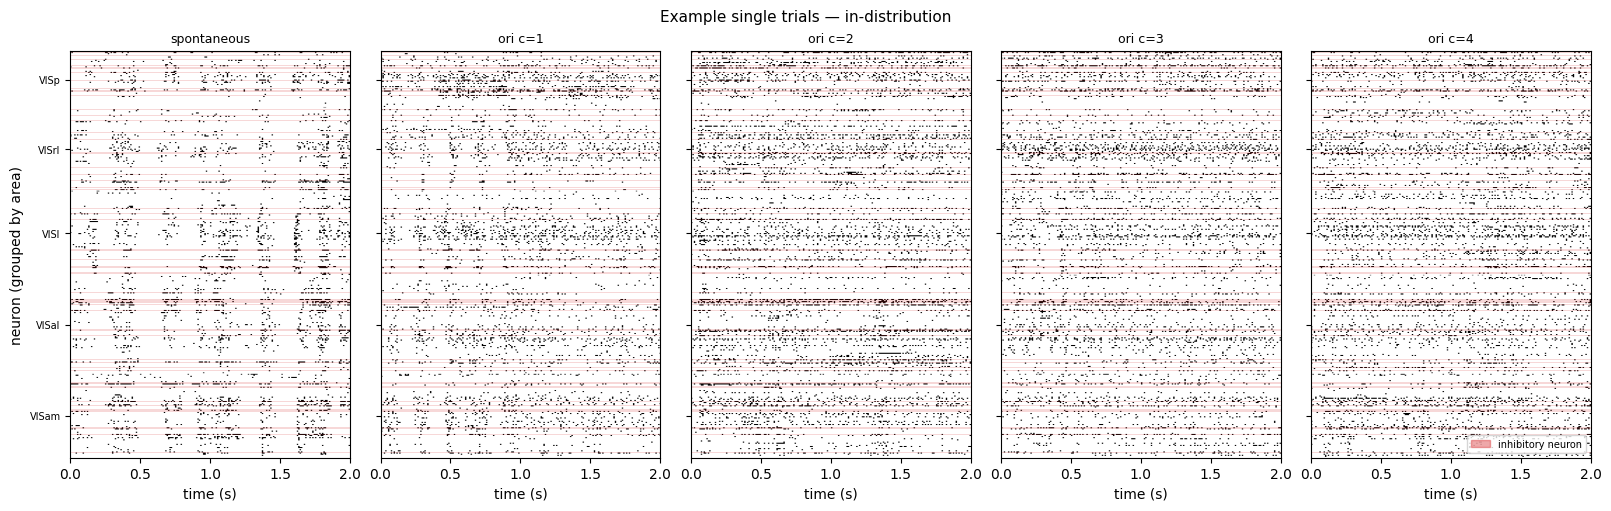

In [9]:
import matplotlib.patches as mpatches

conditions = sorted(np.unique(c_train))
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(3.2 * n_cond, 5),
                         sharey=True, constrained_layout=True)

for ax, cid in zip(axes, conditions):
    idx = np.where(c_train == cid)[0][0]  # first trial of this condition
    raster = z_train[idx]  # (N, T)
    ax.imshow(raster, aspect='auto', cmap='binary', vmin=0, vmax=1,
              extent=[0, T_train * dt, raster.shape[0], 0])
    decorate_raster(ax, bnd, yticks, ylabels)
    label = 'spontaneous' if cid == 0 else f'ori c={cid}'
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('time (s)')

axes[0].set_ylabel('neuron (grouped by area)')

# legend for inhibitory shading
inh_patch = mpatches.Patch(color='C3', alpha=0.4, label='inhibitory neuron')
axes[-1].legend(handles=[inh_patch], fontsize=7, loc='lower right')

fig.suptitle('Example single trials — in-distribution', fontsize=11)
plt.show()


## Mean activity per condition (PSTH)

Trial-averaged population activity and per-area mean firing rate.

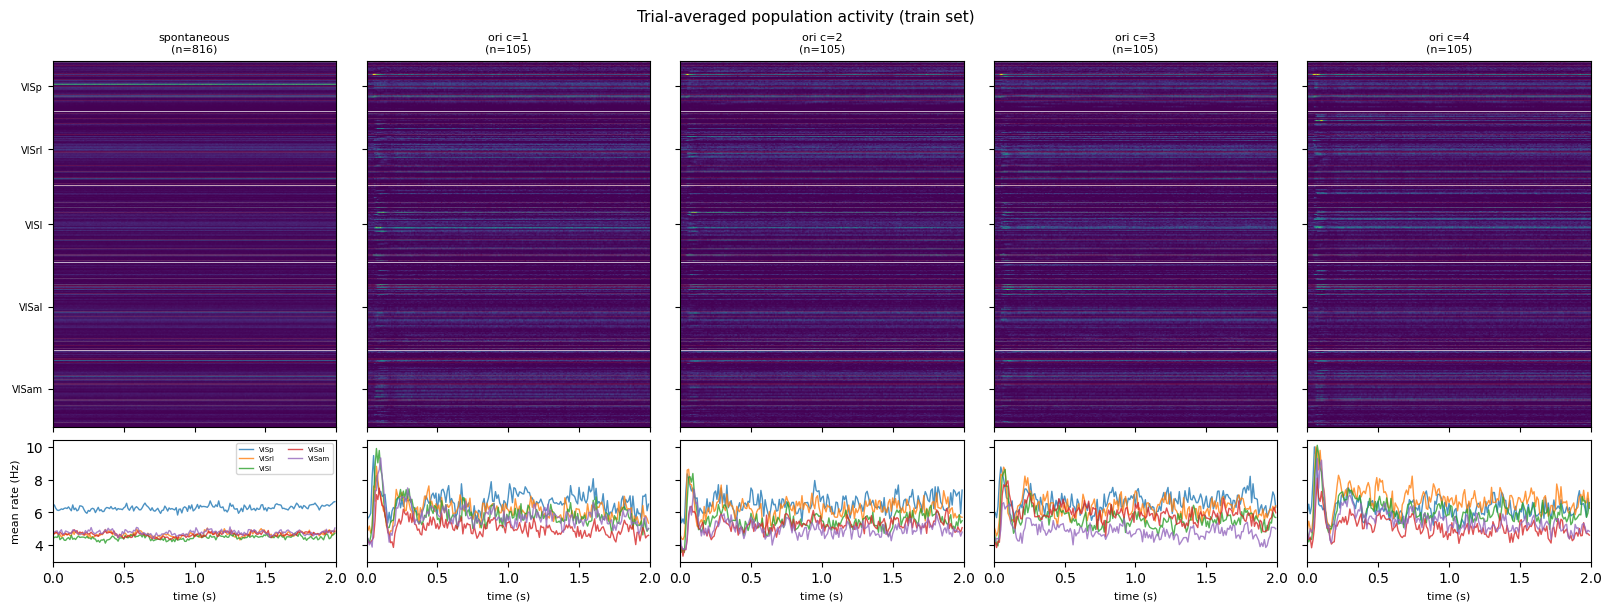

In [10]:
fig, axes = plt.subplots(2, n_cond, figsize=(3.2 * n_cond, 6),
                         gridspec_kw={'height_ratios': [3, 1]},
                         sharex=True, sharey='row', constrained_layout=True)

rate_max = 0.0
for col, cid in enumerate(conditions):
    mask = c_train == cid
    mean_raster = z_train[mask].mean(axis=0)  # (N, T)
    rate = mean_raster / dt  # Hz
    rate_max = max(rate_max, float(rate.max()))

for col, cid in enumerate(conditions):
    mask = c_train == cid
    mean_raster = z_train[mask].mean(axis=0) / dt  # (N, T) in Hz
    n_trials = int(mask.sum())

    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.imshow(mean_raster, aspect='auto', cmap='viridis',
                  vmin=0, vmax=min(rate_max, 100),
                  extent=[0, T_train * dt, mean_raster.shape[0], 0])
    decorate_raster(ax_top, bnd, yticks, ylabels)
    label = 'spontaneous' if cid == 0 else f'ori c={cid}'
    ax_top.set_title(f'{label}\n(n={n_trials})', fontsize=8)

    # per-area mean firing rate trace
    for i, area in enumerate(areas):
        area_mask = area_per_neuron == area
        if area_mask.sum() == 0:
            continue
        trace = mean_raster[area_mask].mean(axis=0)  # (T,)
        ax_bot.plot(t_train, trace, lw=1, label=area, alpha=0.8)
    ax_bot.set_xlabel('time (s)', fontsize=8)
    if col == 0:
        ax_bot.set_ylabel('mean rate (Hz)', fontsize=8)
        ax_bot.legend(fontsize=5, ncol=2)

fig.suptitle('Trial-averaged population activity (train set)', fontsize=11)
plt.show()


## Perturbation data

Trial-averaged rasters and mean firing rate for each opto waveform + sham. LED waveform i(t) shown in orange.

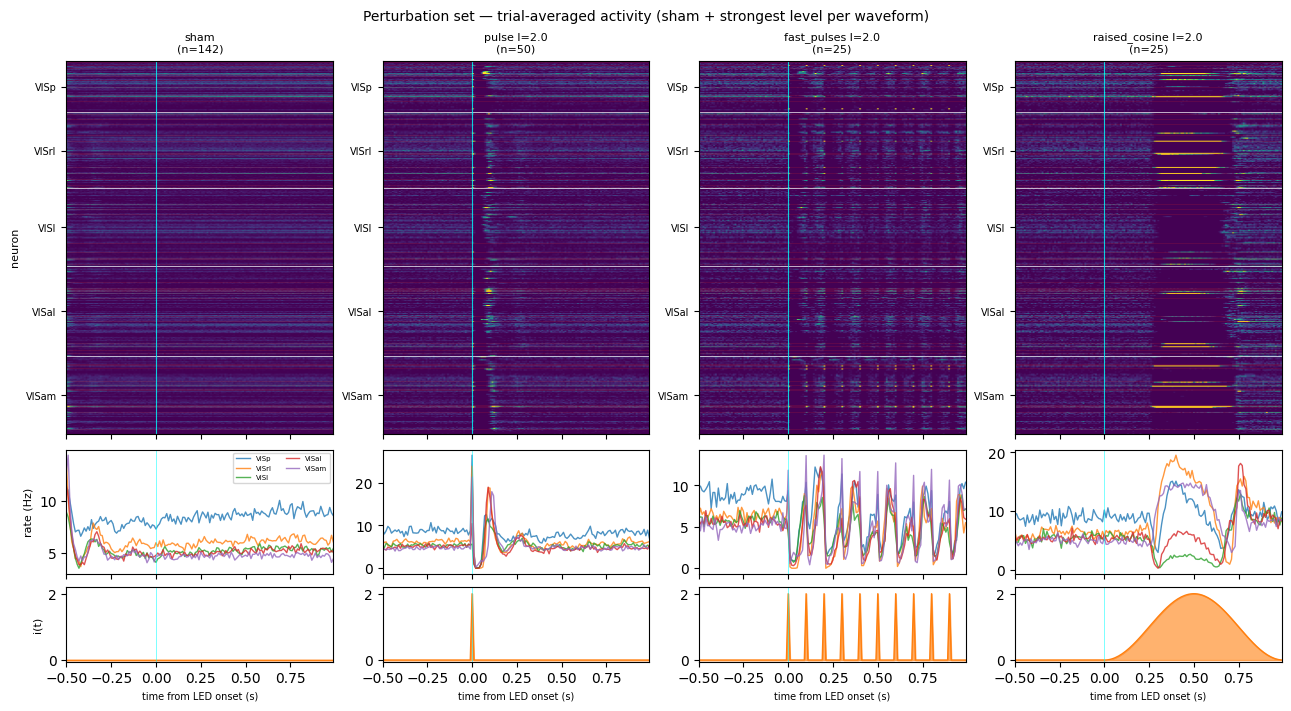

In [11]:
from data.dataloader import perturbation_condition_label

# Show: sham (condition 0) + strongest level (2.0) of each waveform
from data.dataloader import perturbation_condition_from_light
cid_perturb = meta['condition']
show_conditions = sorted({0, 3, 6, 9} & set(np.unique(cid_perturb).tolist()))
n_show = len(show_conditions)

fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 7),
                         gridspec_kw={'height_ratios': [3, 1, 0.6]},
                         sharex=True, constrained_layout=True)

# shared color scale capped at 100 Hz
vmax_perturb = 100.0

for col, cid in enumerate(show_conditions):
    trial_mask = cid_perturb == cid
    mean_raster = z_perturb[trial_mask].mean(axis=0) / dt  # (N, T) Hz
    n_trials = int(trial_mask.sum())
    example_light = light[np.where(trial_mask)[0][0]]  # (T,)

    ax_top = axes[0, col]
    ax_bot = axes[1, col]
    ax_led = axes[2, col]

    # trial-averaged raster
    ax_top.imshow(mean_raster, aspect='auto', cmap='viridis',
                  vmin=0, vmax=vmax_perturb,
                  extent=[t_perturb[0], t_perturb[-1], mean_raster.shape[0], 0])
    decorate_raster(ax_top, bnd, yticks, ylabels)
    ax_top.axvline(0, color='cyan', lw=0.8, alpha=0.8)
    label = perturbation_condition_label(cid)
    ax_top.set_title(f'{label}\n(n={n_trials})', fontsize=8)
    if col == 0:
        ax_top.set_ylabel('neuron', fontsize=8)

    # per-area mean firing rate
    for area in areas:
        area_mask = area_per_neuron == area
        if area_mask.sum() == 0:
            continue
        ax_bot.plot(t_perturb, mean_raster[area_mask].mean(axis=0), lw=1, label=area, alpha=0.8)
    ax_bot.axvline(0, color='cyan', lw=0.6, alpha=0.6)
    if col == 0:
        ax_bot.set_ylabel('rate (Hz)', fontsize=8)
        ax_bot.legend(fontsize=5, ncol=2)

    # LED waveform
    ax_led.fill_between(t_perturb, 0, example_light, color='C1', alpha=0.6)
    ax_led.plot(t_perturb, example_light, color='C1', lw=1)
    ax_led.axvline(0, color='cyan', lw=0.6, alpha=0.6)
    ax_led.set_ylim(-0.05, 2.2)
    ax_led.margins(x=0)
    ax_led.set_xlabel('time from LED onset (s)', fontsize=7)
    if col == 0:
        ax_led.set_ylabel('i(t)', fontsize=8)

fig.suptitle('Perturbation set — trial-averaged activity (sham + strongest level per waveform)', fontsize=10)
plt.show()


## Opto vs sham: population mean firing rate

Direct comparison of mean activity across all neurons and areas.

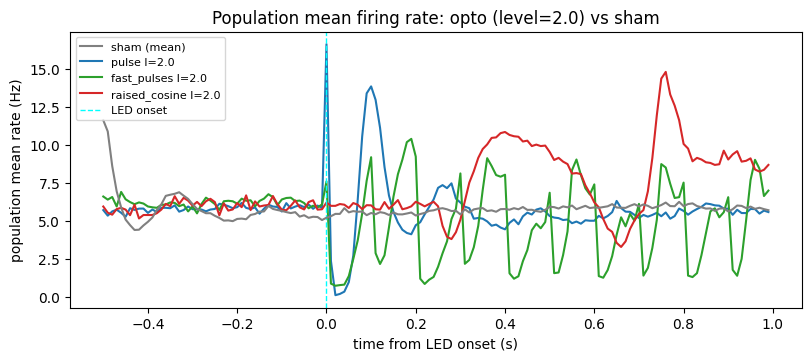

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)

# sham baseline
sham_mask = meta['kind'] == 'sham'
sham_mean = z_perturb[sham_mask].mean(axis=0).mean(axis=0) / dt  # (T,)
ax.plot(t_perturb, sham_mean, color='gray', lw=1.5, label='sham (mean)', zorder=3)

# each opto waveform at strongest level
colors = {'pulse': 'C0', 'fast_pulses': 'C2', 'raised_cosine': 'C3'}
for stim_name, color in colors.items():
    stim_mask = (meta['stimulus_name'] == stim_name) & (meta['level'] == 2.0)
    if not stim_mask.any():
        continue
    opto_mean = z_perturb[stim_mask].mean(axis=0).mean(axis=0) / dt  # (T,)
    ax.plot(t_perturb, opto_mean, color=color, lw=1.5, label=f'{stim_name} l=2.0')

ax.axvline(0, color='cyan', lw=1, ls='--', label='LED onset')
ax.set_xlabel('time from LED onset (s)')
ax.set_ylabel('population mean rate (Hz)')
ax.legend(fontsize=8)
ax.set_title('Population mean firing rate: opto (level=2.0) vs sham')
plt.show()


## Per-neuron trial-averaged traces

All 371 neurons as individual lines. Gray = excitatory, red = inhibitory, blue = outlier.

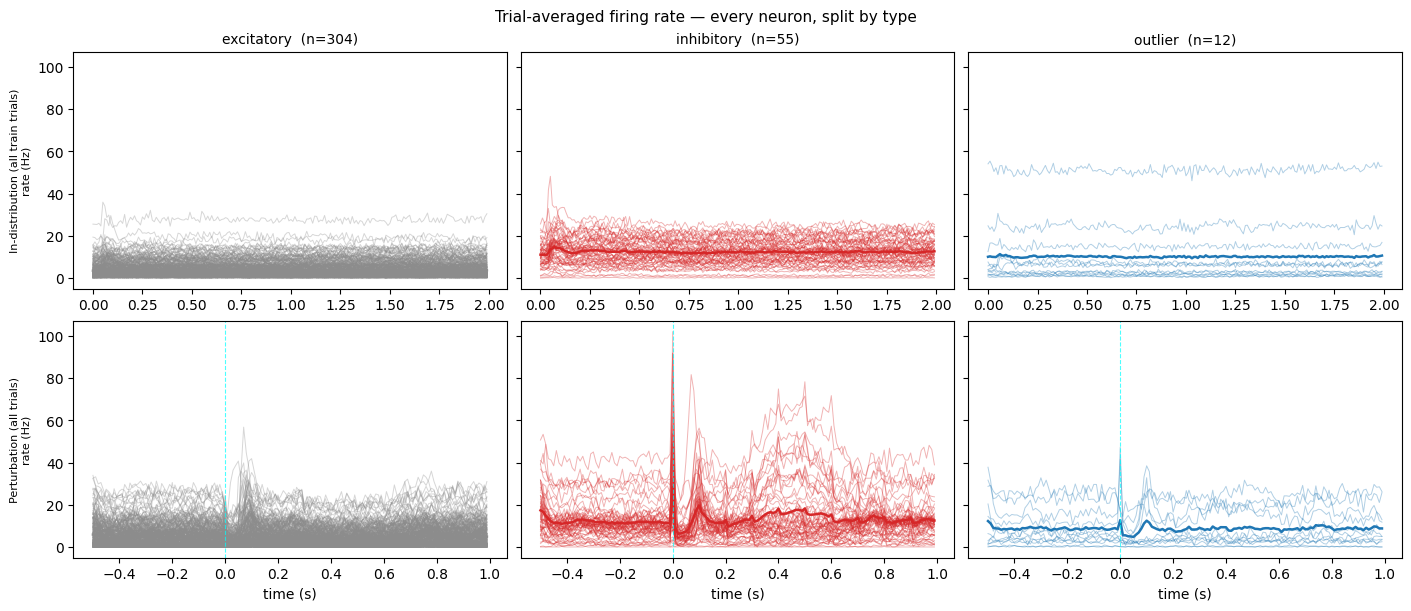

In [13]:
import matplotlib.lines as mlines

neuron_types = [
    ('excitatory',  sign_per_neuron == 1,  '0.55'),
    ('inhibitory',  sign_per_neuron == -1, 'C3'),
    ('outlier',     sign_per_neuron == 0,  'C0'),
]
datasets = [
    ('In-distribution (all train trials)', z_train,   t_train),
    ('Perturbation (all trials)',           z_perturb, t_perturb),
]

fig, axes = plt.subplots(len(datasets), len(neuron_types),
                         figsize=(14, 6), sharey=True, sharex='row',
                         constrained_layout=True)

for row, (ds_title, z, t) in enumerate(datasets):
    mean_rate = z.mean(axis=0) / dt  # (N, T) in Hz
    for col, (type_label, mask, color) in enumerate(neuron_types):
        ax = axes[row, col]
        traces = mean_rate[mask]  # (n_type, T)
        for trace in traces:
            ax.plot(t, trace, color=color, alpha=0.35, lw=0.7)
        # population mean for this type
        ax.plot(t, traces.mean(axis=0), color=color, alpha=1.0, lw=1.8,
                label='mean')
        if row == 0:
            ax.set_title(f'{type_label}  (n={mask.sum()})', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{ds_title}\nrate (Hz)', fontsize=8)
        if row == len(datasets) - 1:
            ax.set_xlabel('time (s)')
        if row == 1:
            ax.axvline(0, color='cyan', lw=0.8, ls='--', alpha=0.7)

fig.suptitle('Trial-averaged firing rate — every neuron, split by type', fontsize=11)
plt.show()


---
## Gaussianity of the feature space (Brain FID)

Brain FID fits a Gaussian to each trial-feature distribution and computes the Fréchet distance between the two Gaussians. Here we check whether that Gaussian assumption actually holds for the in-distribution and perturbation sets.

In [14]:
from perturbation_testing import time_window_features, make_population_oscillation_features
from sklearn.decomposition import PCA
from scipy import stats
from matplotlib.patches import Ellipse

# Both feature functions expect (B, T, N) — transpose from (B, N, T)
z_train_btn   = z_train.transpose(0, 2, 1)
z_test_btn    = z_test.transpose(0, 2, 1)
z_perturb_btn = z_perturb.transpose(0, 2, 1)

# ── time-window features (FID default): (B, N*5) ────────────────────────
feat_train_tw   = time_window_features(z_train_btn)    # (1236, 1855)
feat_test_tw    = time_window_features(z_test_btn)
feat_perturb_tw = time_window_features(z_perturb_btn)

# ── oscillation features (tutorial training loss): (B, n_areas*(n_group+1)) ─
osc_fun = make_population_oscillation_features(area_per_neuron, z_train_btn)
feat_train_osc   = osc_fun(z_train_btn)    # (1236, 20)
feat_test_osc    = osc_fun(z_test_btn)
feat_perturb_osc = osc_fun(z_perturb_btn)

# ── PCA on time-window features (fit on train) ───────────────────────────
pca = PCA(n_components=20).fit(feat_train_tw)
F_train   = pca.transform(feat_train_tw)    # (B, 20)
F_test    = pca.transform(feat_test_tw)
F_perturb = pca.transform(feat_perturb_tw)

print(f'time-window features:   train {feat_train_tw.shape},  '
      f'test {feat_test_tw.shape},  perturb {feat_perturb_tw.shape}')
print(f'oscillation features:   train {feat_train_osc.shape}')
print(f'PCA (on tw-features):   {pca.explained_variance_ratio_[:5].round(3)} '
      f'(top-5 PCs, cumul {pca.explained_variance_ratio_[:5].sum():.2f})')

# condition colour map for scatter plots
cond_colors = {c: f'C{i}' for i, c in enumerate(sorted(np.unique(c_train)))}
cond_labels = {0: 'spontaneous', 1: 'ori c=1', 2: 'ori c=2',
               3: 'ori c=3', 4: 'ori c=4'}


time-window features:   train (1236, 1855),  test (529, 1855),  perturb (442, 1855)
oscillation features:   train (1236, 20)
PCA (on tw-features):   [0.274 0.094 0.07  0.025 0.022] (top-5 PCs, cumul 0.49)


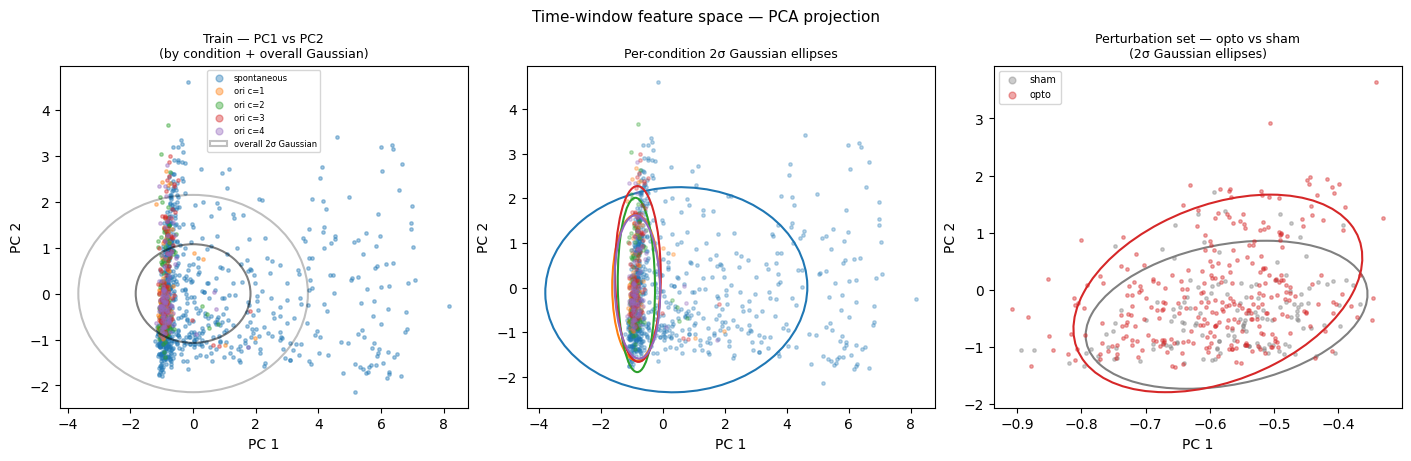

In [15]:
def cov_ellipse(ax, mu, cov, n_std=2, **kw):
    """Draw a covariance ellipse at n_std standard deviations."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(mu, w, h, angle=angle, **kw))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)

# ── left: all train trials in PC1-PC2, coloured by condition ─────────────
ax = axes[0]
for cid in sorted(np.unique(c_train)):
    m = c_train == cid
    ax.scatter(F_train[m, 0], F_train[m, 1], s=6, alpha=0.4,
               color=cond_colors[cid], label=cond_labels[cid])
# overall Gaussian 1σ/2σ ellipse
mu_all  = F_train[:, :2].mean(axis=0)
cov_all = np.cov(F_train[:, :2].T)
for n_std, alpha in [(1, 0.5), (2, 0.25)]:
    cov_ellipse(ax, mu_all, cov_all, n_std=n_std,
                edgecolor='k', facecolor='none', lw=1.5, alpha=alpha,
                label=f'overall {n_std}σ Gaussian' if n_std == 2 else None)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Train — PC1 vs PC2\n(by condition + overall Gaussian)', fontsize=9)
ax.legend(fontsize=6, markerscale=2)

# ── middle: per-condition 2σ Gaussian ellipses ───────────────────────────
ax = axes[1]
for cid in sorted(np.unique(c_train)):
    m = c_train == cid
    pts = F_train[m, :2]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.3, color=cond_colors[cid])
    if pts.shape[0] > 3:
        cov_ellipse(ax, pts.mean(0), np.cov(pts.T), n_std=2,
                    edgecolor=cond_colors[cid], facecolor='none', lw=1.5)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Per-condition 2σ Gaussian ellipses', fontsize=9)

# ── right: perturbation set in same PC space, opto vs sham ───────────────
ax = axes[2]
for kind, color, zord in [('sham', 'gray', 1), ('opto', 'C3', 2)]:
    m = meta['kind'] == kind
    pts = F_perturb[m, :2]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.4, color=color,
               label=kind, zorder=zord)
    if pts.shape[0] > 3:
        cov_ellipse(ax, pts.mean(0), np.cov(pts.T), n_std=2,
                    edgecolor=color, facecolor='none', lw=1.5)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Perturbation set — opto vs sham\n(2σ Gaussian ellipses)', fontsize=9)
ax.legend(fontsize=7, markerscale=2)

fig.suptitle('Time-window feature space — PCA projection', fontsize=11)
plt.show()


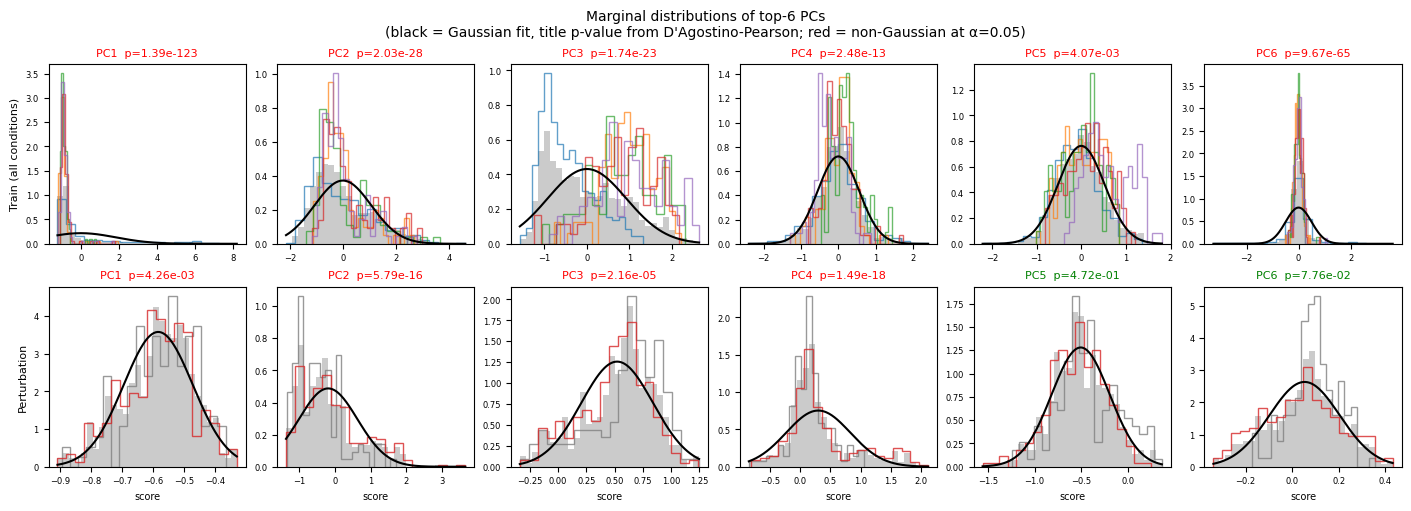

In [16]:
n_dims = 6  # top PCs to inspect
fig, axes = plt.subplots(2, n_dims, figsize=(14, 5), constrained_layout=True)

for col in range(n_dims):
    for row, (label, F, c_vec) in enumerate([
        ('Train (all conditions)', F_train, c_train),
        ('Perturbation',           F_perturb, None),
    ]):
        ax = axes[row, col]
        x = F[:, col]

        # overall histogram
        ax.hist(x, bins=30, density=True, color='0.6', alpha=0.5, label='all')

        # per-condition histograms (train only)
        if c_vec is not None:
            for cid in sorted(np.unique(c_vec)):
                xc = x[c_vec == cid]
                ax.hist(xc, bins=20, density=True, histtype='step',
                        color=cond_colors[cid], alpha=0.7, lw=1)
        else:
            # opto / sham split for perturbation
            for kind, color in [('sham', 'gray'), ('opto', 'C3')]:
                xk = x[meta['kind'] == kind]
                ax.hist(xk, bins=20, density=True, histtype='step',
                        color=color, alpha=0.8, lw=1, label=kind)

        # Gaussian fit to the overall distribution
        mu_x, std_x = x.mean(), x.std()
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mu_x, std_x), 'k-', lw=1.5, label='Gaussian fit')

        # normality test
        stat, pval = stats.normaltest(x)
        ax.set_title(f'PC{col+1}  p={pval:.2e}', fontsize=8,
                     color='green' if pval > 0.05 else 'red')
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == 1:
            ax.set_xlabel('score', fontsize=7)
        ax.tick_params(labelsize=6)

fig.suptitle("Marginal distributions of top-6 PCs\n"
             "(black = Gaussian fit, title p-value from D'Agostino-Pearson; "
             "red = non-Gaussian at α=0.05)", fontsize=10)
plt.show()


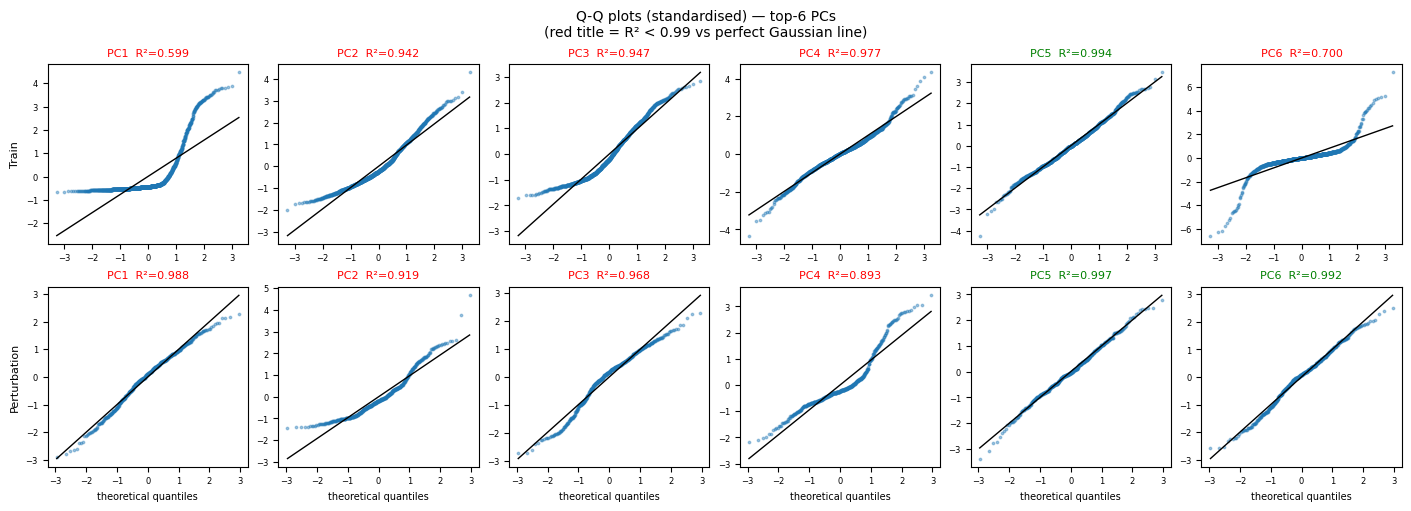

In [17]:
n_dims = 6
fig, axes = plt.subplots(2, n_dims, figsize=(14, 5), constrained_layout=True)

for col in range(n_dims):
    for row, (label, F) in enumerate([
        ('Train', F_train),
        ('Perturbation', F_perturb),
    ]):
        ax = axes[row, col]
        x = (F[:, col] - F[:, col].mean()) / F[:, col].std()
        (osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm')
        ax.scatter(osm, osr, s=3, alpha=0.4, color='C0')
        ax.plot(osm, slope * np.array(osm) + intercept, 'k-', lw=1)
        ax.set_title(f'PC{col+1}  R²={r**2:.3f}', fontsize=8,
                     color='green' if r**2 > 0.99 else 'red')
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == 1:
            ax.set_xlabel('theoretical quantiles', fontsize=7)
        ax.tick_params(labelsize=6)

fig.suptitle('Q-Q plots (standardised) — top-6 PCs\n'
             '(red title = R² < 0.99 vs perfect Gaussian line)', fontsize=10)
plt.show()


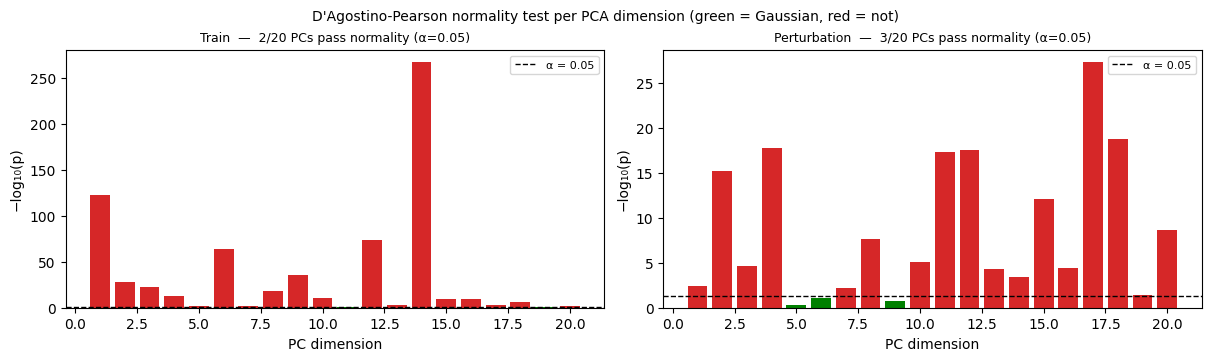


Per-condition: fraction of PC dims passing normality (α=0.05)
  c=0 (spontaneous         )  n=816    1/20 pass  (5%)
  c=1 (ori c=1             )  n=105    10/20 pass  (50%)
  c=2 (ori c=2             )  n=105    8/20 pass  (40%)
  c=3 (ori c=3             )  n=105    11/20 pass  (55%)
  c=4 (ori c=4             )  n=105    9/20 pass  (45%)


In [18]:
n_pcs = F_train.shape[1]  # 20
pvals_train   = [stats.normaltest(F_train[:, k]).pvalue   for k in range(n_pcs)]
pvals_perturb = [stats.normaltest(F_perturb[:, k]).pvalue for k in range(n_pcs)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)

for ax, pvals, label in [
    (axes[0], pvals_train,   'Train'),
    (axes[1], pvals_perturb, 'Perturbation'),
]:
    colors = ['green' if p > 0.05 else 'C3' for p in pvals]
    ax.bar(range(1, n_pcs + 1), [-np.log10(p) for p in pvals], color=colors)
    ax.axhline(-np.log10(0.05), color='k', ls='--', lw=1, label='α = 0.05')
    n_pass = sum(p > 0.05 for p in pvals)
    ax.set_xlabel('PC dimension')
    ax.set_ylabel('−log₁₀(p)')
    ax.set_title(f'{label}  —  {n_pass}/{n_pcs} PCs pass normality (α=0.05)', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("D'Agostino-Pearson normality test per PCA dimension"
             " (green = Gaussian, red = not)", fontsize=10)
plt.show()

# Per-condition check: are conditions individually more Gaussian?
print('\nPer-condition: fraction of PC dims passing normality (α=0.05)')
for cid in sorted(np.unique(c_train)):
    F_c = F_train[c_train == cid]
    pvs = [stats.normaltest(F_c[:, k]).pvalue for k in range(n_pcs)]
    n_pass = sum(p > 0.05 for p in pvs)
    print(f'  c={cid} ({cond_labels[cid]:<20s})  n={F_c.shape[0]}  '
          f'  {n_pass}/{n_pcs} pass  ({100*n_pass/n_pcs:.0f}%)')
